# Hierarchical observer scaffold

Purpose: make the modeling path explicit before committing to one theory. The notebook ties the paper equations to the local `data01_direction4priors.csv` columns, then keeps each transformation as a small function.

The research question can still change. The stable contract is:
- inputs: trial-level stimulus, prior condition, subject/block identity, optional history variables
- output: reported estimate angle and model probability of that estimate
- model families: Basic Bayesian/BLS, Switching/MAP, sampling, hierarchical subject pooling, online prior learning

In [1]:
from pathlib import Path
import importlib.util

REQUIRED_PACKAGES = ["numpy", "pandas", "matplotlib"]
OPTIONAL_PACKAGES = ["scipy", "pymc", "arviz"]

def package_status(names):
    return {name: importlib.util.find_spec(name) is not None for name in names}

required_status = package_status(REQUIRED_PACKAGES)
optional_status = package_status(OPTIONAL_PACKAGES)
missing_required = [name for name, ok in required_status.items() if not ok]

print("Required package status:", required_status)
print("Optional package status:", optional_status)

if missing_required:
    raise ModuleNotFoundError(
        "Missing required local packages: " + ", ".join(missing_required) +
        "\nInstall them in the notebook kernel environment before running the scaffold."
    )

Required package status: {'numpy': True, 'pandas': True, 'matplotlib': True}
Optional package status: {'scipy': False, 'pymc': False, 'arviz': False}


In [2]:
import math
from dataclasses import dataclass, asdict
from typing import Callable, Dict, Iterable, Mapping, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## Simple local path setup

The behavioral CSV is loaded from the remote GitHub raw URL. These local paths are only for PDFs, notes, and output files. The setup supports running from the repository root or from inside the new modeling folder.

In [3]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR
RESEARCH_DIR = PROJECT_ROOT

OUTPUT_DIR = RESEARCH_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PAPER_PATHS = {
    "paper": PROJECT_ROOT / "A-Switching-Observer-for-Human-Perceptual-Estimati.pdf",
    "model_explainer": PROJECT_ROOT / "Model_explainer.pdf",
    "hierarchical_stepwise": PROJECT_ROOT / "Hierarchical_explicit_stepwise.pdf",
    "rt_walkthrough": PROJECT_ROOT / "rt_to_adaptation_explorarion_data_walkthrough.pdf",
}

for label, path in {"PROJECT_ROOT": PROJECT_ROOT, "RESEARCH_DIR": RESEARCH_DIR, **PAPER_PATHS}.items():
    print(f"{label}: {path} | exists={path.exists()}")

PROJECT_ROOT: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1 | exists=True
RESEARCH_DIR: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1 | exists=True
paper: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\A-Switching-Observer-for-Human-Perceptual-Estimati.pdf | exists=True
model_explainer: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\Model_explainer.pdf | exists=False
hierarchical_stepwise: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\Hierarchical_explicit_stepwise.pdf | exists=False
rt_walkthrough: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\rt_to_adaptation_explorarion_data_walkthrough.pdf | exists=False


## Scaffold contract

This table is the notebook's map from the paper/model equations to the dataset. Keep edits here when the theory changes, so later cells stay readable.

In [4]:
RAW_INPUT_COLUMNS = [
    "trial_index", "trial_time", "response_arrow_start_angle",
    "motion_direction", "motion_coherence",
    "estimate_x", "estimate_y",
    "reaction_time", "raw_response_time",
    "prior_std", "prior_mean",
    "subject_id", "experiment_name", "experiment_id", "session_id", "run_id",
]

REQUIRED_COLUMNS = [
    "motion_direction", "motion_coherence", "estimate_x", "estimate_y",
    "prior_std", "prior_mean", "subject_id", "session_id", "run_id", "trial_index",
]

DERIVED_COLUMNS = [
    "block_id", "trials_into_block", "estimate_deg",
    "block_order_within_subject", "prev_block_id", "prev_prior_std", "prev_prior_mean",
    "prev_session_id", "prev_run_id", "same_session_prev",
    "prior_std_change", "prior_width_changed", "transition_direction", "transition_type",
    "motion_offset_from_prior", "estimate_offset_from_prior",
    "error_from_motion", "abs_error_from_motion", "signed_prior_pull",
    "distance_to_motion", "distance_to_prior", "closer_to_prior_than_motion",
    "previous_motion_direction", "previous_motion_coherence", "previous_error_from_motion",
    "previous_prior_confidence_proxy", "current_prior_confidence_target",
    "initial_prior_confidence_proxy", "within_block_learning_progress", "prior_confidence_t_proxy",
    "trial_bin",
]

OUTCOME_COLUMNS = ["estimate_deg", "error_from_motion", "abs_error_from_motion"]

PREDICTOR_SETS = {
    "task_conditions": ["motion_direction", "motion_coherence", "prior_std", "prior_mean"],
    "hierarchy": ["subject_id", "session_id", "run_id", "block_id"],
    "between_block_context": ["block_order_within_subject", "prev_prior_std", "same_session_prev", "prior_std_change", "transition_direction", "transition_type"],
    "within_block_history": ["trial_index", "trials_into_block", "trial_bin", "previous_motion_direction", "previous_motion_coherence"],
    "confidence_learning_path": ["previous_prior_confidence_proxy", "initial_prior_confidence_proxy", "within_block_learning_progress", "prior_confidence_t_proxy"],
    "switching_proxy": ["distance_to_motion", "distance_to_prior", "closer_to_prior_than_motion"],
    "response_setup_optional": ["response_arrow_start_angle", "reaction_time", "raw_response_time"],
}

EQUATION_MAP = pd.DataFrame([
    {
        "paper_step": "true direction d",
        "dataset_terms": "motion_direction",
        "derived_terms": "motion_offset_from_prior",
        "function_anchor": "prepare_trials",
        "model_role": "stimulus value shown to the subject; also feedback after response",
    },
    {
        "paper_step": "sensory reliability / likelihood",
        "dataset_terms": "motion_coherence",
        "derived_terms": "coherence_idx, k_llh_by_coherence",
        "function_anchor": "make_hierarchical_design, vm_pdf_deg",
        "model_role": "higher coherence should map to stronger likelihood concentration",
    },
    {
        "paper_step": "prior mean and prior strength",
        "dataset_terms": "prior_mean, prior_std",
        "derived_terms": "prior_std_idx, k_prior_by_std",
        "function_anchor": "build_prior_grid",
        "model_role": "block-level prior centered at 225 deg with width 10/20/40/80",
    },
    {
        "paper_step": "posterior = likelihood x prior",
        "dataset_terms": "motion_direction, motion_coherence, prior_mean, prior_std",
        "derived_terms": "posterior_grid",
        "function_anchor": "combine_likelihood_and_prior",
        "model_role": "Basic Bayesian integration; later readout decides BLS/MAP/sample",
    },
    {
        "paper_step": "switching / responsibility",
        "dataset_terms": "motion_direction, prior_mean, prior_std, motion_coherence",
        "derived_terms": "responsibility_peaked, sub_posterior_peaked, sub_posterior_uniform",
        "function_anchor": "compute_responsibility",
        "model_role": "mixture route: estimate may come from prior-like or likelihood-like component",
    },
    {
        "paper_step": "readout",
        "dataset_terms": "estimate_x, estimate_y",
        "derived_terms": "estimate_deg",
        "function_anchor": "readout_distribution",
        "model_role": "MAP = switching peak, BLS = circular mean, sampling = posterior draw",
    },
    {
        "paper_step": "motor noise + lapse",
        "dataset_terms": "estimate_x, estimate_y",
        "derived_terms": "observed_estimate_probability",
        "function_anchor": "apply_motor_and_lapse, negative_log_likelihood",
        "model_role": "turns model percept into probability of the actual response",
    },
    {
        "paper_step": "between-block carryover",
        "dataset_terms": "subject_id, session_id, run_id, prior_std",
        "derived_terms": "prev_prior_std, transition_type, same_session_prev, prior_std_change",
        "function_anchor": "build_block_context, add_block_context",
        "model_role": "defines what prior confidence is carried into the start of the current block",
    },
    {
        "paper_step": "hyperprior summary / initial prior confidence",
        "dataset_terms": "prior_std, prev_prior_std, trials_into_block",
        "derived_terms": "initial_prior_confidence_proxy, prior_confidence_t_proxy",
        "function_anchor": "add_prior_confidence_scaffold",
        "model_role": "scaffold proxy for the hidden belief over prior strength; later replaced by fitted latent parameters",
    },
    {
        "paper_step": "online prior learning / feedback loop",
        "dataset_terms": "trial_index, block_id, prior_std, prev_prior_std",
        "derived_terms": "trials_into_block, within_block_learning_progress, prior_confidence_t_proxy",
        "function_anchor": "add_history_columns, add_prior_confidence_scaffold, update_online_prior_state, simulate_prior_confidence_learning",
        "model_role": "uses block history to move prior confidence/precision from its carried-in start toward the current block target",
    },
    {
        "paper_step": "hierarchical pooling",
        "dataset_terms": "subject_id, session_id, run_id",
        "derived_terms": "subject_idx, block_idx",
        "function_anchor": "make_hierarchical_design",
        "model_role": "subject parameters share group-level structure instead of fitting each subject alone",
    },
])

EQUATION_MAP

,paper_step,dataset_terms,derived_terms,function_anchor,model_role
0,true direction d,motion_direction,motion_offset_from_prior,prepare_trials,stimulus value shown to the subject; also feed...
1,sensory reliability / likelihood,motion_coherence,"coherence_idx, k_llh_by_coherence","make_hierarchical_design, vm_pdf_deg",higher coherence should map to stronger likeli...
2,prior mean and prior strength,"prior_mean, prior_std","prior_std_idx, k_prior_by_std",build_prior_grid,block-level prior centered at 225 deg with wid...
3,posterior = likelihood x prior,"motion_direction, motion_coherence, prior_mean...",posterior_grid,combine_likelihood_and_prior,Basic Bayesian integration; later readout deci...
4,switching / responsibility,"motion_direction, prior_mean, prior_std, motio...","responsibility_peaked, sub_posterior_peaked, s...",compute_responsibility,mixture route: estimate may come from prior-li...
5,readout,"estimate_x, estimate_y",estimate_deg,readout_distribution,"MAP = switching peak, BLS = circular mean, sam..."
6,motor noise + lapse,"estimate_x, estimate_y",observed_estimate_probability,"apply_motor_and_lapse, negative_log_likelihood",turns model percept into probability of the ac...
7,between-block carryover,"subject_id, session_id, run_id, prior_std","prev_prior_std, transition_type, same_session_...","build_block_context, add_block_context",defines what prior confidence is carried into ...
8,hyperprior summary / initial prior confidence,"prior_std, prev_prior_std, trials_into_block","initial_prior_confidence_proxy, prior_confiden...",add_prior_confidence_scaffold,scaffold proxy for the hidden belief over prio...
9,online prior learning / feedback loop,"trial_index, block_id, prior_std, prev_prior_std","trials_into_block, within_block_learning_progr...","add_history_columns, add_prior_confidence_scaf...",uses block history to move prior confidence/pr...


## Load and inspect raw data

The first pass only verifies the raw table. Modeling cells should use `prepare_trials(raw)` rather than modifying `raw` directly.

In [5]:
REMOTE_CSV_URL = "https://raw.githubusercontent.com/steevelaquitaine/projInference/refs/heads/gh-pages/data/csv/data01_direction4priors.csv"

def load_trials(csv_url: str = REMOTE_CSV_URL) -> pd.DataFrame:
    df = pd.read_csv(csv_url)
    return df

In [6]:
def assert_required_columns(df: pd.DataFrame, required: Iterable[str] = REQUIRED_COLUMNS) -> None:
    missing = sorted(set(required) - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def summarize_columns(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "position": range(1, len(df.columns) + 1),
        "column": df.columns,
        "dtype": [df[c].dtype for c in df.columns],
        "missing_n": [df[c].isna().sum() for c in df.columns],
        "missing_pct": [df[c].isna().mean() * 100 for c in df.columns],
        "unique_n": [df[c].nunique(dropna=True) for c in df.columns],
    })


raw = load_trials()
print(f"raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
display(summarize_columns(raw))

display(pd.crosstab(raw["prior_std"], raw["motion_coherence"], margins=True))

raw shape: 83,213 rows x 16 columns


,position,column,dtype,missing_n,missing_pct,unique_n
0,1,trial_index,int64,0,0.000000,226
1,2,trial_time,float64,0,0.000000,82822
2,3,response_arrow_start_angle,float64,31850,38.275269,360
3,4,motion_direction,int64,0,0.000000,36
4,5,motion_coherence,float64,0,0.000000,3
5,6,estimate_x,float64,3,0.003605,25858
6,7,estimate_y,float64,3,0.003605,25858
7,8,reaction_time,float64,31855,38.281278,51136
8,9,raw_response_time,float64,31855,38.281278,51358
9,10,prior_std,int64,0,0.000000,4


motion_coherence,0.06,0.12,0.24,All
prior_std,,,,
10,8132,5596,2844,16572
20,8172,5925,2372,16469
40,7784,5803,2324,15911
80,16665,11589,6007,34261
All,40753,28913,13547,83213


## Feature builders

These functions make the dataset model-ready while preserving the paper's names. Angles are circular, so all differences use wrapped degrees.

In [7]:
def wrap_signed_deg(angle):
    """Wrap an angular difference to [-180, 180)."""
    return ((np.asarray(angle) + 180) % 360) - 180


def wrap_unsigned_deg(angle):
    """Wrap an angle to [0, 360)."""
    return np.asarray(angle) % 360


def xy_to_deg(x, y):
    """Convert response endpoint x/y into an unsigned response angle."""
    return wrap_unsigned_deg(np.degrees(np.arctan2(y, x)))


BLOCK_COLS = ["subject_id", "session_id", "run_id"]


def prior_confidence_proxy_from_std(prior_std):
    """Scaffold proxy: narrower prior_std means higher prior confidence/precision."""
    std = np.asarray(prior_std, dtype=float)
    return 1.0 / np.square(np.deg2rad(std))


def add_block_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["block_id"] = (
        out["subject_id"].astype(str)
        + "_s" + out["session_id"].astype(str)
        + "_r" + out["run_id"].astype(str)
    )
    out = out.sort_values(["subject_id", "session_id", "run_id", "trial_index"]).reset_index(drop=True)
    out["trials_into_block"] = out.groupby("block_id").cumcount() + 1
    return out


def build_block_context(df: pd.DataFrame) -> pd.DataFrame:
    """One row per block, including previous-block labels for carryover analyses."""
    blocks = (
        df.groupby(BLOCK_COLS, as_index=False)
        .agg(
            block_id=("block_id", "first"),
            prior_std=("prior_std", "first"),
            prior_mean=("prior_mean", "first"),
            block_n_trials=("trial_index", "size"),
            experiment_id=("experiment_id", "first"),
        )
        .sort_values(BLOCK_COLS)
        .reset_index(drop=True)
    )

    subject_blocks = blocks.groupby("subject_id", sort=False)
    blocks["block_order_within_subject"] = subject_blocks.cumcount() + 1
    blocks["prev_block_id"] = subject_blocks["block_id"].shift(1)
    blocks["prev_prior_std"] = subject_blocks["prior_std"].shift(1)
    blocks["prev_prior_mean"] = subject_blocks["prior_mean"].shift(1)
    blocks["prev_session_id"] = subject_blocks["session_id"].shift(1)
    blocks["prev_run_id"] = subject_blocks["run_id"].shift(1)

    has_previous = blocks["prev_prior_std"].notna()
    blocks["same_session_prev"] = has_previous & blocks["session_id"].eq(blocks["prev_session_id"])
    blocks["prior_std_change"] = blocks["prior_std"] - blocks["prev_prior_std"]
    blocks["prior_width_changed"] = has_previous & blocks["prior_std_change"].ne(0)

    blocks["transition_direction"] = np.select(
        [
            ~has_previous,
            blocks["prior_std_change"].eq(0),
            blocks["prior_std_change"].gt(0),
            blocks["prior_std_change"].lt(0),
        ],
        ["first_block", "repeat_prior", "narrower_to_wider", "wider_to_narrower"],
        default="unknown",
    )

    blocks["transition_type"] = np.select(
        [
            ~has_previous,
            blocks["same_session_prev"] & blocks["prior_std"].eq(80) & blocks["prev_prior_std"].eq(80),
            blocks["same_session_prev"] & blocks["prior_std"].eq(80) & blocks["prev_prior_std"].isin([10, 20, 40]),
            blocks["same_session_prev"] & blocks["prior_std_change"].eq(0),
            blocks["same_session_prev"] & blocks["prior_std_change"].ne(0),
            has_previous & ~blocks["same_session_prev"],
        ],
        [
            "first_block",
            "repeat_80",
            "transition_to_80",
            "same_session_repeat_prior",
            "same_session_prior_transition",
            "cross_session_previous",
        ],
        default="unknown",
    )
    return blocks


def add_block_context(df: pd.DataFrame) -> pd.DataFrame:
    block_context = build_block_context(df)
    merge_columns = BLOCK_COLS + [
        "block_n_trials", "block_order_within_subject", "prev_block_id",
        "prev_prior_std", "prev_prior_mean", "prev_session_id", "prev_run_id",
        "same_session_prev", "prior_std_change", "prior_width_changed",
        "transition_direction", "transition_type",
    ]
    return df.merge(block_context[merge_columns], on=BLOCK_COLS, how="left")


def add_prior_confidence_scaffold(df: pd.DataFrame, carryover_weight: float = 0.35, learning_tau: float = 45.0) -> pd.DataFrame:
    """Add the scaffold path: previous block -> initial confidence -> within-block confidence_t."""
    out = df.copy()
    target = prior_confidence_proxy_from_std(out["prior_std"])
    previous = prior_confidence_proxy_from_std(out["prev_prior_std"])
    has_same_session_previous = out["prev_prior_std"].notna() & out["same_session_prev"].fillna(False)

    out["current_prior_confidence_target"] = target
    out["previous_prior_confidence_proxy"] = np.where(has_same_session_previous, previous, target)

    carried_start = (
        (1.0 - carryover_weight) * out["current_prior_confidence_target"]
        + carryover_weight * out["previous_prior_confidence_proxy"]
    )
    out["initial_prior_confidence_proxy"] = np.where(
        has_same_session_previous,
        carried_start,
        out["current_prior_confidence_target"],
    )

    progress = 1.0 - np.exp(-np.maximum(out["trials_into_block"] - 1, 0) / learning_tau)
    out["within_block_learning_progress"] = progress
    out["prior_confidence_t_proxy"] = (
        out["initial_prior_confidence_proxy"]
        + progress * (out["current_prior_confidence_target"] - out["initial_prior_confidence_proxy"])
    )
    return out


def add_circular_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["estimate_deg"] = xy_to_deg(out["estimate_x"], out["estimate_y"])
    out["motion_offset_from_prior"] = wrap_signed_deg(out["motion_direction"] - out["prior_mean"])
    out["estimate_offset_from_prior"] = wrap_signed_deg(out["estimate_deg"] - out["prior_mean"])
    out["error_from_motion"] = wrap_signed_deg(out["estimate_deg"] - out["motion_direction"])
    out["abs_error_from_motion"] = np.abs(out["error_from_motion"])

    direction_to_prior = wrap_signed_deg(out["prior_mean"] - out["motion_direction"])
    out["signed_prior_pull"] = np.sign(direction_to_prior) * out["error_from_motion"]
    out["distance_to_motion"] = np.abs(wrap_signed_deg(out["estimate_deg"] - out["motion_direction"]))
    out["distance_to_prior"] = np.abs(wrap_signed_deg(out["estimate_deg"] - out["prior_mean"]))
    out["closer_to_prior_than_motion"] = out["distance_to_prior"] < out["distance_to_motion"]
    return out


def add_history_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    group = out.groupby("block_id", sort=False)
    out["previous_motion_direction"] = group["motion_direction"].shift(1)
    out["previous_motion_coherence"] = group["motion_coherence"].shift(1)
    out["previous_error_from_motion"] = group["error_from_motion"].shift(1)
    return out


def add_trial_bins(df: pd.DataFrame, bins=(0, 45, 110, np.inf), labels=("early", "middle", "late")) -> pd.DataFrame:
    out = df.copy()
    out["trial_bin"] = pd.cut(out["trials_into_block"], bins=bins, labels=labels, right=True)
    return out


def prepare_trials(df: pd.DataFrame) -> pd.DataFrame:
    out = add_block_id(df)
    out = add_block_context(out)
    out = add_circular_columns(out)
    out = add_history_columns(out)
    out = add_trial_bins(out)
    out = add_prior_confidence_scaffold(out)
    return out


trials = prepare_trials(raw)
print(f"prepared shape: {trials.shape[0]:,} rows x {trials.shape[1]} columns")
display(trials[[*REQUIRED_COLUMNS, *DERIVED_COLUMNS]].head())

prepared shape: 83,213 rows x 48 columns


,motion_direction,motion_coherence,estimate_x,estimate_y,prior_std,prior_mean,subject_id,session_id,run_id,trial_index,block_id,trials_into_block,estimate_deg,block_order_within_subject,prev_block_id,prev_prior_std,prev_prior_mean,prev_session_id,prev_run_id,same_session_prev,prior_std_change,prior_width_changed,transition_direction,transition_type,motion_offset_from_prior,estimate_offset_from_prior,error_from_motion,abs_error_from_motion,signed_prior_pull,distance_to_motion,distance_to_prior,closer_to_prior_than_motion,previous_motion_direction,previous_motion_coherence,previous_error_from_motion,previous_prior_confidence_proxy,current_prior_confidence_target,initial_prior_confidence_proxy,within_block_learning_progress,prior_confidence_t_proxy,trial_bin
0,225,0.12,-1.749685,-1.785666,10,225,1,1,1,1,1_s1_r1,1,225.583113,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,0,0.583113,0.583113,0.583113,0.000000,0.583113,0.583113,False,NaN,NaN,NaN,32.828064,32.828064,32.828064,0.000000,32.828064,early
1,225,0.12,-1.819693,-1.714269,10,225,1,1,1,2,1_s1_r1,2,223.291282,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,0,-1.708718,-1.708718,1.708718,-0.000000,1.708718,1.708718,False,225.0,0.12,0.583113,32.828064,32.828064,32.828064,0.021977,32.828064,early
2,235,0.06,-1.562674,-1.951422,10,225,1,1,1,3,1_s1_r1,3,231.312691,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,10,6.312691,-3.687309,3.687309,3.687309,3.687309,6.312691,False,225.0,0.12,-1.708718,32.828064,32.828064,32.828064,0.043471,32.828064,early
3,225,0.06,-1.601388,-1.919781,10,225,1,1,1,4,1_s1_r1,4,230.166776,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,0,5.166776,5.166776,5.166776,0.000000,5.166776,5.166776,False,235.0,0.06,-3.687309,32.828064,32.828064,32.828064,0.064493,32.828064,early
4,215,0.24,-1.639461,-1.887371,10,225,1,1,1,5,1_s1_r1,5,229.020860,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,-10,4.020860,14.020860,14.020860,14.020860,14.020860,4.020860,True,225.0,0.06,5.166776,32.828064,32.828064,32.828064,0.085053,32.828064,early


In [8]:
def validate_prepared_trials(df: pd.DataFrame) -> None:
    required = set(REQUIRED_COLUMNS + DERIVED_COLUMNS)
    missing = sorted(required - set(df.columns))
    if missing:
        raise AssertionError(f"Prepared table missing columns: {missing}")

    block_prior_counts = df.groupby("block_id")["prior_std"].nunique()
    if block_prior_counts.max() != 1:
        raise AssertionError("At least one block has more than one prior_std.")

    estimate_radius = np.sqrt(df["estimate_x"] ** 2 + df["estimate_y"] ** 2)
    print("subjects:", df["subject_id"].nunique())
    print("blocks:", df["block_id"].nunique())
    print("prior_std:", sorted(df["prior_std"].dropna().unique()))
    print("motion_coherence:", sorted(df["motion_coherence"].dropna().unique()))
    print("transition_type counts:")
    print(build_block_context(df)["transition_type"].value_counts().to_string())
    print("median estimate radius:", float(np.nanmedian(estimate_radius)))

validate_prepared_trials(trials)

subjects: 12
blocks: 389
prior_std: [np.int64(10), np.int64(20), np.int64(40), np.int64(80)]
motion_coherence: [np.float64(0.06), np.float64(0.12), np.float64(0.24)]
transition_type counts:
transition_type
same_session_prior_transition    174
transition_to_80                 104
cross_session_previous            69
repeat_80                         30
first_block                       12
median estimate radius: 2.5


## Analysis-facing tables

`model_df` is the narrow table passed to model functions. It keeps the outcome, task predictors, hierarchy keys, and the minimal history variables. This is the place to add or remove predictors when testing a new theory.

In [9]:
def make_model_frame(df: pd.DataFrame, require_estimate: bool = True) -> pd.DataFrame:
    columns = [
        "subject_id", "session_id", "run_id", "block_id", "trial_index", "trials_into_block", "trial_bin",
        "block_order_within_subject", "prev_block_id", "prev_prior_std", "prev_prior_mean",
        "prev_session_id", "prev_run_id", "same_session_prev", "prior_std_change",
        "prior_width_changed", "transition_direction", "transition_type",
        "motion_direction", "motion_coherence", "prior_std", "prior_mean",
        "motion_offset_from_prior", "estimate_offset_from_prior",
        "estimate_deg", "error_from_motion", "abs_error_from_motion", "signed_prior_pull",
        "distance_to_motion", "distance_to_prior", "closer_to_prior_than_motion",
        "previous_motion_direction", "previous_motion_coherence", "previous_error_from_motion",
        "previous_prior_confidence_proxy", "current_prior_confidence_target",
        "initial_prior_confidence_proxy", "within_block_learning_progress", "prior_confidence_t_proxy",
        "response_arrow_start_angle", "reaction_time", "experiment_id",
    ]
    keep = [c for c in columns if c in df.columns]
    out = df[keep].copy()
    if require_estimate:
        out = out.dropna(subset=["estimate_deg"])
    return out


def encode_index(series: pd.Series, name: str) -> tuple[pd.Series, pd.Index]:
    categories = pd.Index(sorted(series.dropna().unique()))
    indexer = pd.Series(pd.Categorical(series, categories=categories).codes, index=series.index, name=name)
    return indexer, categories


def make_hierarchical_design(model_df: pd.DataFrame) -> dict:
    """Return arrays that can be passed to PyMC, Stan, NumPyro, or a custom optimizer."""
    d = model_df.copy()
    d["subject_idx"], subject_levels = encode_index(d["subject_id"], "subject_idx")
    d["block_idx"], block_levels = encode_index(d["block_id"], "block_idx")
    d["coherence_idx"], coherence_levels = encode_index(d["motion_coherence"], "coherence_idx")
    d["prior_std_idx"], prior_std_levels = encode_index(d["prior_std"], "prior_std_idx")
    d["transition_idx"], transition_levels = encode_index(d["transition_type"], "transition_idx")

    return {
        "table": d,
        "y_estimate_deg": d["estimate_deg"].to_numpy(float),
        "motion_direction": d["motion_direction"].to_numpy(float),
        "motion_coherence": d["motion_coherence"].to_numpy(float),
        "prior_std": d["prior_std"].to_numpy(float),
        "prior_mean": d["prior_mean"].to_numpy(float),
        "prev_prior_std": d["prev_prior_std"].to_numpy(float),
        "prior_std_change": d["prior_std_change"].to_numpy(float),
        "initial_prior_confidence_proxy": d["initial_prior_confidence_proxy"].to_numpy(float),
        "within_block_learning_progress": d["within_block_learning_progress"].to_numpy(float),
        "prior_confidence_t_proxy": d["prior_confidence_t_proxy"].to_numpy(float),
        "subject_idx": d["subject_idx"].to_numpy(int),
        "block_idx": d["block_idx"].to_numpy(int),
        "coherence_idx": d["coherence_idx"].to_numpy(int),
        "prior_std_idx": d["prior_std_idx"].to_numpy(int),
        "transition_idx": d["transition_idx"].to_numpy(int),
        "levels": {
            "subject": subject_levels,
            "block": block_levels,
            "coherence": coherence_levels,
            "prior_std": prior_std_levels,
            "transition": transition_levels,
        },
    }

model_df = make_model_frame(trials)
design = make_hierarchical_design(model_df)
print(model_df.shape)
display(model_df.head())
print({key: list(value)[:8] for key, value in design["levels"].items()})

(83210, 42)


,subject_id,session_id,run_id,block_id,trial_index,trials_into_block,trial_bin,block_order_within_subject,prev_block_id,prev_prior_std,prev_prior_mean,prev_session_id,prev_run_id,same_session_prev,prior_std_change,prior_width_changed,transition_direction,transition_type,motion_direction,motion_coherence,prior_std,prior_mean,motion_offset_from_prior,estimate_offset_from_prior,estimate_deg,error_from_motion,abs_error_from_motion,signed_prior_pull,distance_to_motion,distance_to_prior,closer_to_prior_than_motion,previous_motion_direction,previous_motion_coherence,previous_error_from_motion,previous_prior_confidence_proxy,current_prior_confidence_target,initial_prior_confidence_proxy,within_block_learning_progress,prior_confidence_t_proxy,response_arrow_start_angle,reaction_time,experiment_id
0,1,1,1,1_s1_r1,1,1,early,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,225,0.12,10,225,0,0.583113,225.583113,0.583113,0.583113,0.000000,0.583113,0.583113,False,NaN,NaN,NaN,32.828064,32.828064,32.828064,0.000000,32.828064,NaN,NaN,11
1,1,1,1,1_s1_r1,2,2,early,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,225,0.12,10,225,0,-1.708718,223.291282,-1.708718,1.708718,-0.000000,1.708718,1.708718,False,225.0,0.12,0.583113,32.828064,32.828064,32.828064,0.021977,32.828064,NaN,NaN,11
2,1,1,1,1_s1_r1,3,3,early,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,235,0.06,10,225,10,6.312691,231.312691,-3.687309,3.687309,3.687309,3.687309,6.312691,False,225.0,0.12,-1.708718,32.828064,32.828064,32.828064,0.043471,32.828064,NaN,NaN,11
3,1,1,1,1_s1_r1,4,4,early,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,225,0.06,10,225,0,5.166776,230.166776,5.166776,5.166776,0.000000,5.166776,5.166776,False,235.0,0.06,-3.687309,32.828064,32.828064,32.828064,0.064493,32.828064,NaN,NaN,11
4,1,1,1,1_s1_r1,5,5,early,1,NaN,NaN,NaN,NaN,NaN,False,NaN,False,first_block,first_block,215,0.24,10,225,-10,4.020860,229.020860,14.020860,14.020860,14.020860,14.020860,4.020860,True,225.0,0.06,5.166776,32.828064,32.828064,32.828064,0.085053,32.828064,NaN,NaN,11


{'subject': [1, 2, 3, 4, 5, 6, 7, 8], 'block': ['10_s1_r1', '10_s1_r2', '10_s1_r3', '10_s1_r4', '10_s1_r5', '10_s2_r10', '10_s2_r6', '10_s2_r7'], 'coherence': [0.06, 0.12, 0.24], 'prior_std': [10, 20, 40, 80], 'transition': ['cross_session_previous', 'first_block', 'repeat_80', 'same_session_prior_transition', 'transition_to_80']}


## Carryover-to-estimate path

This is the working path for the next section:

`previous block context -> initial prior confidence at current block start -> within-block confidence learning -> predicted estimate distribution`

The confidence values in this section are scaffold proxies. They make the data path visible before fitting. Later, `carryover_weight`, `learning_tau`, and subject-specific confidence parameters should be estimated from the response likelihood.

In [10]:
CONFIDENCE_FLOW_COLUMNS = [
    "subject_id", "session_id", "run_id", "block_id", "block_order_within_subject",
    "prior_std", "prev_prior_std", "same_session_prev", "transition_direction", "transition_type",
    "trials_into_block", "trial_bin",
    "previous_prior_confidence_proxy", "initial_prior_confidence_proxy",
    "within_block_learning_progress", "prior_confidence_t_proxy",
    "motion_direction", "motion_coherence", "estimate_deg", "error_from_motion", "signed_prior_pull",
]


def summarize_block_transitions(df: pd.DataFrame) -> pd.DataFrame:
    blocks = build_block_context(df)
    return (
        blocks.groupby(["transition_type", "transition_direction"], observed=True)
        .agg(
            blocks=("block_id", "nunique"),
            subjects=("subject_id", "nunique"),
            mean_trials=("block_n_trials", "mean"),
        )
        .reset_index()
        .sort_values(["transition_type", "transition_direction"])
    )


def preview_confidence_flow(df: pd.DataFrame, transition_types=("repeat_80", "transition_to_80"), n_per_type: int = 8) -> pd.DataFrame:
    rows = []
    for transition_type in transition_types:
        sub = df[df["transition_type"].eq(transition_type)].copy()
        if sub.empty:
            continue
        first_block = sub["block_id"].iloc[0]
        rows.append(sub[sub["block_id"].eq(first_block)].head(n_per_type))
    if not rows:
        return pd.DataFrame(columns=CONFIDENCE_FLOW_COLUMNS)
    return pd.concat(rows, ignore_index=True)[CONFIDENCE_FLOW_COLUMNS]


display(summarize_block_transitions(trials))
display(preview_confidence_flow(trials))


,transition_type,transition_direction,blocks,subjects,mean_trials
0,cross_session_previous,narrower_to_wider,15,10,214.133333
1,cross_session_previous,repeat_prior,18,11,219.222222
2,cross_session_previous,wider_to_narrower,36,12,211.083333
3,first_block,first_block,12,12,213.416667
4,repeat_80,repeat_prior,30,12,220.800000
5,same_session_prior_transition,narrower_to_wider,52,12,206.884615
6,same_session_prior_transition,wider_to_narrower,122,12,209.385246
7,transition_to_80,narrower_to_wider,104,12,220.846154


,subject_id,session_id,run_id,block_id,block_order_within_subject,prior_std,prev_prior_std,same_session_prev,transition_direction,transition_type,trials_into_block,trial_bin,previous_prior_confidence_proxy,initial_prior_confidence_proxy,within_block_learning_progress,prior_confidence_t_proxy,motion_direction,motion_coherence,estimate_deg,error_from_motion,signed_prior_pull
0,1,2,10,1_s2_r10,10,80,80.0,True,repeat_prior,repeat_80,1,early,0.512938,0.512938,0.000000,0.512938,135,0.06,241.625932,106.625932,106.625932
1,1,2,10,1_s2_r10,10,80,80.0,True,repeat_prior,repeat_80,2,early,0.512938,0.512938,0.021977,0.512938,275,0.06,193.497477,-81.502523,81.502523
2,1,2,10,1_s2_r10,10,80,80.0,True,repeat_prior,repeat_80,3,early,0.512938,0.512938,0.043471,0.512938,195,0.12,206.102548,11.102548,11.102548
3,1,2,10,1_s2_r10,10,80,80.0,True,repeat_prior,repeat_80,4,early,0.512938,0.512938,0.064493,0.512938,305,0.12,193.497477,-111.502523,111.502523
4,1,2,10,1_s2_r10,10,80,80.0,True,repeat_prior,repeat_80,5,early,0.512938,0.512938,0.085053,0.512938,155,0.06,156.828178,1.828178,1.828178
5,1,2,10,1_s2_r10,10,80,80.0,True,repeat_prior,repeat_80,6,early,0.512938,0.512938,0.105161,0.512938,295,0.06,292.046218,-2.953782,2.953782
6,1,2,10,1_s2_r10,10,80,80.0,True,repeat_prior,repeat_80,7,early,0.512938,0.512938,0.124827,0.512938,325,0.24,296.629880,-28.370120,28.370120
7,1,2,10,1_s2_r10,10,80,80.0,True,repeat_prior,repeat_80,8,early,0.512938,0.512938,0.144060,0.512938,345,0.24,318.402276,-26.597724,26.597724
8,1,1,2,1_s1_r2,2,80,10.0,True,narrower_to_wider,transition_to_80,1,early,32.828064,11.823232,0.000000,11.823232,255,0.06,201.518886,-53.481114,53.481114
9,1,1,2,1_s1_r2,2,80,10.0,True,narrower_to_wider,transition_to_80,2,early,32.828064,11.823232,0.021977,11.574664,235,0.06,214.123958,-20.876042,20.876042


## Descriptive checks before fitting

These are not the final model. They show whether the variables behave like the paper says: lower coherence should increase error, narrower priors should pull estimates more strongly, and early/late bins can test fast prior learning.

,prior_std,motion_coherence,trial_bin,n,median_abs_error,mean_prior_pull,mean_error
0,10,0.06,early,1699,12.670968,4.918911,0.178429
1,10,0.06,middle,2386,11.969512,5.220575,-0.708750
2,10,0.06,late,4047,13.206680,5.639577,0.013324
3,10,0.12,early,1134,12.357847,4.041122,0.200041
4,10,0.12,middle,1692,10.879442,3.664101,0.646904
5,10,0.12,late,2770,11.376983,5.073286,-0.335290
6,10,0.24,early,587,8.623017,1.595202,2.200282
7,10,0.24,middle,862,8.620056,2.227904,-0.276200
8,10,0.24,late,1395,9.036411,1.776621,0.851453
9,20,0.06,early,1776,19.880429,10.659147,0.990877


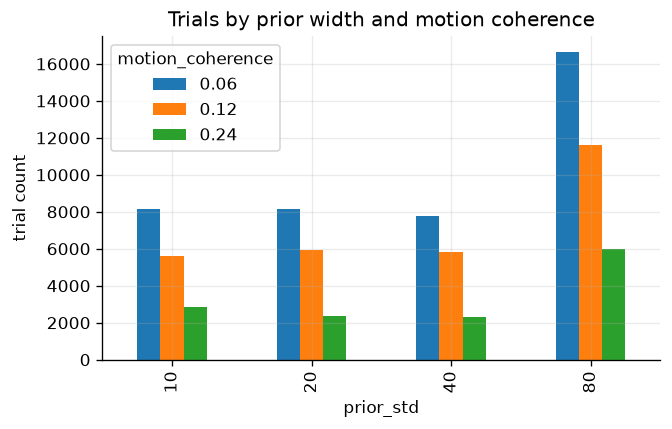

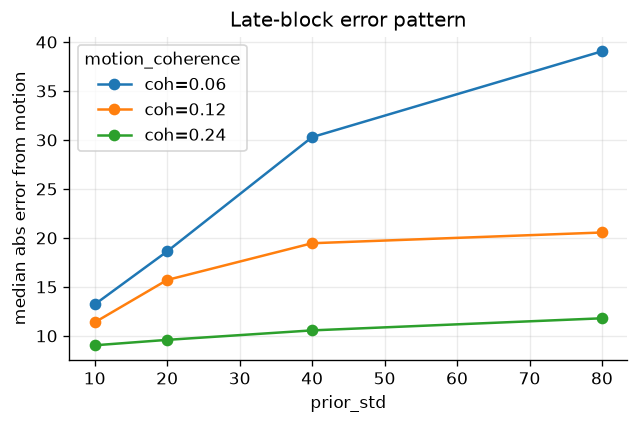

In [11]:
def summarize_condition_errors(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["prior_std", "motion_coherence", "trial_bin"], observed=True)
        .agg(
            n=("estimate_deg", "size"),
            median_abs_error=("abs_error_from_motion", "median"),
            mean_prior_pull=("signed_prior_pull", "mean"),
            mean_error=("error_from_motion", "mean"),
        )
        .reset_index()
    )


def plot_condition_counts(df: pd.DataFrame):
    counts = pd.crosstab(df["prior_std"], df["motion_coherence"])
    fig, ax = plt.subplots(figsize=(6, 3.5))
    counts.plot(kind="bar", ax=ax)
    ax.set_xlabel("prior_std")
    ax.set_ylabel("trial count")
    ax.set_title("Trials by prior width and motion coherence")
    ax.legend(title="motion_coherence")
    return fig, ax


def plot_error_by_condition(summary: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for coh, sub in summary.groupby("motion_coherence"):
        late = sub[sub["trial_bin"] == "late"].sort_values("prior_std")
        ax.plot(late["prior_std"], late["median_abs_error"], marker="o", label=f"coh={coh}")
    ax.set_xlabel("prior_std")
    ax.set_ylabel("median abs error from motion")
    ax.set_title("Late-block error pattern")
    ax.legend(title="motion_coherence")
    return fig, ax

condition_summary = summarize_condition_errors(model_df)
display(condition_summary.head(12))
plot_condition_counts(model_df)
plot_error_by_condition(condition_summary)
plt.show()

## Experimental Distribution Compiler

This section turns the prepared trial table into stable empirical targets. These outputs should be treated as fixed references for later model fitting and comparison: `distribution_df`, `subject_condition_summary`, `group_condition_summary`, `empirical_histograms`, `transition_distribution_summary`, and `model_targets`.

The compiler is intentionally data-facing. It does not fit the HB model yet; it defines the distributions that HB, Basic Bayesian, Switching, Sampling, and sensory-only models must explain.

In [12]:
ANGLE_BIN_EDGES = np.arange(-180, 181, 10)
CONFLICT_BIN_EDGES = [0, 10, 20, 40, 80, 120, 180]
CONFIDENCE_BIN_EDGES = [0, 1, 4, 12, np.inf]
CONFIDENCE_BIN_LABELS = ["very_low", "low", "medium", "high"]


def sem(series):
    values = pd.Series(series).dropna()
    if len(values) <= 1:
        return np.nan
    return values.std(ddof=1) / np.sqrt(len(values))


def angle_bin_labels(edges):
    return [f"{int(left)}:{int(right)}" for left, right in zip(edges[:-1], edges[1:])]


def add_switching_proxy_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure prior-like vs motion-like descriptive columns exist."""
    out = df.copy()
    out["distance_to_motion"] = np.abs(wrap_signed_deg(out["estimate_deg"] - out["motion_direction"]))
    out["distance_to_prior"] = np.abs(wrap_signed_deg(out["estimate_deg"] - out["prior_mean"]))
    out["closer_to_prior_than_motion"] = out["distance_to_prior"] < out["distance_to_motion"]
    return out


def define_distribution_bins(df: pd.DataFrame) -> pd.DataFrame:
    """Own the bin definitions used by all empirical distribution summaries."""
    out = add_switching_proxy_columns(df)
    angle_labels = angle_bin_labels(ANGLE_BIN_EDGES)
    out["motion_offset_bin"] = pd.cut(
        out["motion_offset_from_prior"], bins=ANGLE_BIN_EDGES, labels=angle_labels, include_lowest=True
    )
    out["estimate_offset_bin"] = pd.cut(
        out["estimate_offset_from_prior"], bins=ANGLE_BIN_EDGES, labels=angle_labels, include_lowest=True
    )
    out["error_bin"] = pd.cut(
        out["error_from_motion"], bins=ANGLE_BIN_EDGES, labels=angle_labels, include_lowest=True
    )
    out["conflict_bin"] = pd.cut(
        np.abs(out["motion_offset_from_prior"]), bins=CONFLICT_BIN_EDGES, include_lowest=True
    )
    out["confidence_bin"] = pd.cut(
        out["prior_confidence_t_proxy"], bins=CONFIDENCE_BIN_EDGES, labels=CONFIDENCE_BIN_LABELS, include_lowest=True
    )
    return out


DISTRIBUTION_COLUMNS = [
    "subject_id", "session_id", "run_id", "block_id", "trial_index", "trials_into_block", "trial_bin",
    "block_order_within_subject", "prior_std", "prior_mean", "prev_prior_std", "same_session_prev",
    "prior_std_change", "transition_direction", "transition_type",
    "motion_direction", "motion_coherence", "motion_offset_from_prior", "motion_offset_bin", "conflict_bin",
    "estimate_deg", "estimate_offset_from_prior", "estimate_offset_bin",
    "error_from_motion", "abs_error_from_motion", "error_bin", "signed_prior_pull",
    "distance_to_motion", "distance_to_prior", "closer_to_prior_than_motion",
    "previous_motion_direction", "previous_motion_coherence", "previous_error_from_motion",
    "previous_prior_confidence_proxy", "initial_prior_confidence_proxy", "within_block_learning_progress",
    "prior_confidence_t_proxy", "confidence_bin", "reaction_time", "experiment_id",
]


def make_distribution_frame(df: pd.DataFrame, require_estimate: bool = True) -> pd.DataFrame:
    required = ["motion_offset_from_prior", "estimate_offset_from_prior", "error_from_motion", "prior_confidence_t_proxy"]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(
            "Distribution compiler is missing derived columns: "
            + ", ".join(missing)
            + ". Re-run prepare_trials(raw), then model_df = make_model_frame(trials)."
        )
    binned = define_distribution_bins(df)
    keep = [column for column in DISTRIBUTION_COLUMNS if column in binned.columns]
    out = binned[keep].copy()
    if require_estimate:
        out = out.dropna(subset=["estimate_deg"])
    return out


def compile_trial_counts(distribution_df: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    if group_cols is None:
        group_cols = ["prior_std", "motion_coherence", "trial_bin", "transition_type"]
    return (
        distribution_df.groupby(group_cols, observed=True, dropna=False)
        .agg(
            n_trials=("estimate_deg", "size"),
            n_subjects=("subject_id", "nunique"),
            n_blocks=("block_id", "nunique"),
        )
        .reset_index()
    )


def compile_subject_condition_summary(distribution_df: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    if group_cols is None:
        group_cols = ["subject_id", "prior_std", "motion_coherence", "trial_bin", "transition_type"]
    return (
        distribution_df.groupby(group_cols, observed=True, dropna=False)
        .agg(
            n_trials=("estimate_deg", "size"),
            n_blocks=("block_id", "nunique"),
            median_abs_error=("abs_error_from_motion", "median"),
            mean_signed_prior_pull=("signed_prior_pull", "mean"),
            prior_like_rate=("closer_to_prior_than_motion", "mean"),
            mean_estimate_offset=("estimate_offset_from_prior", "mean"),
            std_estimate_offset=("estimate_offset_from_prior", "std"),
            mean_prior_confidence=("prior_confidence_t_proxy", "mean"),
            median_reaction_time=("reaction_time", "median"),
        )
        .reset_index()
    )


def compile_group_condition_summary(subject_condition_summary: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    if group_cols is None:
        group_cols = ["prior_std", "motion_coherence", "trial_bin", "transition_type"]
    return (
        subject_condition_summary.groupby(group_cols, observed=True, dropna=False)
        .agg(
            n_subjects=("subject_id", "nunique"),
            mean_abs_error=("median_abs_error", "mean"),
            sem_abs_error=("median_abs_error", sem),
            mean_prior_pull=("mean_signed_prior_pull", "mean"),
            sem_prior_pull=("mean_signed_prior_pull", sem),
            mean_prior_like_rate=("prior_like_rate", "mean"),
            sem_prior_like_rate=("prior_like_rate", sem),
            mean_prior_confidence=("mean_prior_confidence", "mean"),
            sem_prior_confidence=("mean_prior_confidence", sem),
        )
        .reset_index()
    )


def compile_empirical_histograms(distribution_df: pd.DataFrame, group_cols=None, target_bin_cols=None) -> pd.DataFrame:
    if group_cols is None:
        group_cols = ["prior_std", "motion_coherence", "trial_bin", "transition_type", "motion_offset_bin"]
    if target_bin_cols is None:
        target_bin_cols = {
            "estimate_offset_from_prior": "estimate_offset_bin",
            "error_from_motion": "error_bin",
        }

    histogram_parts = []
    for target, bin_col in target_bin_cols.items():
        counts = (
            distribution_df.groupby(group_cols + [bin_col], observed=True, dropna=False)
            .agg(n_trials=(bin_col, "size"))
            .reset_index()
        )
        counts["total_trials"] = counts.groupby(group_cols, observed=True, dropna=False)["n_trials"].transform("sum")
        counts["probability"] = counts["n_trials"] / counts["total_trials"]
        counts["target"] = target
        counts = counts.rename(columns={bin_col: "target_bin"})
        histogram_parts.append(counts)

    return pd.concat(histogram_parts, ignore_index=True)


def compile_transition_distributions(distribution_df: pd.DataFrame, transition_types=None) -> pd.DataFrame:
    if transition_types is None:
        transition_types = [
            "repeat_80", "transition_to_80",
            "same_session_repeat_prior", "same_session_prior_transition",
        ]
    d = distribution_df[distribution_df["transition_type"].isin(transition_types)].copy()
    return (
        d.groupby(["subject_id", "transition_type", "trial_bin", "motion_coherence"], observed=True, dropna=False)
        .agg(
            n_trials=("estimate_deg", "size"),
            n_blocks=("block_id", "nunique"),
            prior_like_rate=("closer_to_prior_than_motion", "mean"),
            median_abs_error=("abs_error_from_motion", "median"),
            mean_signed_prior_pull=("signed_prior_pull", "mean"),
            mean_prior_confidence=("prior_confidence_t_proxy", "mean"),
            median_reaction_time=("reaction_time", "median"),
        )
        .reset_index()
    )


def compile_model_targets(distribution_df, count_summary, subject_condition_summary, group_condition_summary, empirical_histograms, transition_distribution_summary) -> dict:
    return {
        "trial_table": distribution_df,
        "count_summary": count_summary,
        "subject_summary": subject_condition_summary,
        "group_summary": group_condition_summary,
        "histograms": empirical_histograms,
        "transition_summary": transition_distribution_summary,
    }


distribution_df = make_distribution_frame(model_df)
count_summary = compile_trial_counts(distribution_df)
subject_condition_summary = compile_subject_condition_summary(distribution_df)
group_condition_summary = compile_group_condition_summary(subject_condition_summary)
empirical_histograms = compile_empirical_histograms(distribution_df)
transition_distribution_summary = compile_transition_distributions(distribution_df)
model_targets = compile_model_targets(
    distribution_df,
    count_summary,
    subject_condition_summary,
    group_condition_summary,
    empirical_histograms,
    transition_distribution_summary,
)

print("model target keys:", list(model_targets.keys()))
print("distribution_df shape:", distribution_df.shape)
display(count_summary.head())
display(subject_condition_summary.head())
display(empirical_histograms.head())
display(transition_distribution_summary.head())


model target keys: ['trial_table', 'count_summary', 'subject_summary', 'group_summary', 'histograms', 'transition_summary']
distribution_df shape: (83210, 40)


,prior_std,motion_coherence,trial_bin,transition_type,n_trials,n_subjects,n_blocks
0,10,0.06,early,cross_session_previous,443,10,20
1,10,0.06,early,first_block,84,4,4
2,10,0.06,early,same_session_prior_transition,1172,12,52
3,10,0.06,middle,cross_session_previous,628,10,20
4,10,0.06,middle,first_block,123,4,4


,subject_id,prior_std,motion_coherence,trial_bin,transition_type,n_trials,n_blocks,median_abs_error,mean_signed_prior_pull,prior_like_rate,mean_estimate_offset,std_estimate_offset,mean_prior_confidence,median_reaction_time
0,1,10,0.06,early,cross_session_previous,18,1,7.291831,3.196372,0.277778,-5.210126,11.092476,32.828064,NaN
1,1,10,0.06,early,first_block,24,1,5.166776,5.315982,0.375000,2.970438,5.851996,32.828064,NaN
2,1,10,0.06,early,same_session_prior_transition,137,6,8.472490,6.326854,0.357664,-4.733589,27.865363,26.162472,1.615768
3,1,10,0.06,middle,cross_session_previous,35,1,9.416887,9.291138,0.514286,-2.036122,8.662945,32.828064,NaN
4,1,10,0.06,middle,first_block,33,1,9.437198,6.926096,0.424242,5.826545,7.046626,32.828064,NaN


,prior_std,motion_coherence,trial_bin,transition_type,motion_offset_bin,target_bin,n_trials,total_trials,probability,target
0,10,0.06,early,cross_session_previous,-30:-20,-80:-70,1,25,0.04,estimate_offset_from_prior
1,10,0.06,early,cross_session_previous,-30:-20,-40:-30,2,25,0.08,estimate_offset_from_prior
2,10,0.06,early,cross_session_previous,-30:-20,-30:-20,1,25,0.04,estimate_offset_from_prior
3,10,0.06,early,cross_session_previous,-30:-20,-20:-10,1,25,0.04,estimate_offset_from_prior
4,10,0.06,early,cross_session_previous,-30:-20,-10:0,4,25,0.16,estimate_offset_from_prior


,subject_id,transition_type,trial_bin,motion_coherence,n_trials,n_blocks,prior_like_rate,median_abs_error,mean_signed_prior_pull,mean_prior_confidence,median_reaction_time
0,1,repeat_80,early,0.06,72,3,0.486111,30.616108,17.337264,0.512938,1.422233
1,1,repeat_80,early,0.12,48,3,0.187500,10.993244,12.638548,0.512938,1.621575
2,1,repeat_80,early,0.24,15,3,0.066667,8.371060,3.341943,0.512938,1.242903
3,1,repeat_80,middle,0.06,87,3,0.471264,33.134862,21.228952,0.512938,1.536421
4,1,repeat_80,middle,0.12,60,3,0.166667,14.303191,0.824086,0.512938,1.413810


## Core circular model functions

These functions are small on purpose. They are the replaceable blocks for MAP/switching, BLS/basic Bayesian, sampling, and later hierarchical or online variants.

In [13]:
def make_angle_grid(start: int = 0, stop: int = 360, step: int = 1) -> np.ndarray:
    return np.arange(start, stop, step, dtype=float)


def normalize_pdf(pdf: np.ndarray, axis: Optional[int] = None) -> np.ndarray:
    pdf = np.asarray(pdf, dtype=float)
    total = np.sum(pdf, axis=axis, keepdims=True)
    return np.divide(pdf, total, out=np.zeros_like(pdf, dtype=float), where=total > 0)


def vm_pdf_deg(angle_grid: np.ndarray, center_deg: float, kappa: float) -> np.ndarray:
    """Discrete von Mises-like density on a degree grid, normalized by summing over the grid."""
    delta_rad = np.deg2rad(wrap_signed_deg(angle_grid - center_deg))
    log_pdf = kappa * (np.cos(delta_rad) - 1.0)
    pdf = np.exp(log_pdf - np.nanmax(log_pdf))
    return normalize_pdf(pdf)


def kappa_from_sd_deg(sd_deg: float, floor: float = 1e-3) -> float:
    """Starting approximation only: concentration grows as circular SD shrinks."""
    sd_rad = np.deg2rad(max(float(sd_deg), floor))
    return 1.0 / (sd_rad ** 2)


def build_prior_grid(angle_grid: np.ndarray, prior_mean: float, prior_std: float, mix_weight: float = 1.0, k_prior: Optional[float] = None) -> np.ndarray:
    kappa = kappa_from_sd_deg(prior_std) if k_prior is None else float(k_prior)
    peaked = vm_pdf_deg(angle_grid, prior_mean, kappa)
    uniform = np.ones_like(angle_grid, dtype=float) / len(angle_grid)
    return normalize_pdf(mix_weight * peaked + (1.0 - mix_weight) * uniform)


def build_likelihood_grid(angle_grid: np.ndarray, measurement_deg: float, k_llh: float) -> np.ndarray:
    return vm_pdf_deg(angle_grid, measurement_deg, k_llh)


def combine_likelihood_and_prior(likelihood: np.ndarray, prior: np.ndarray) -> np.ndarray:
    return normalize_pdf(np.asarray(likelihood) * np.asarray(prior))


def circular_mean_deg(angle_grid: np.ndarray, weights: np.ndarray) -> float:
    theta = np.deg2rad(angle_grid)
    z = np.sum(weights * np.exp(1j * theta))
    return float(np.degrees(np.angle(z)) % 360)


def readout_distribution(angle_grid: np.ndarray, posterior: np.ndarray, readout: str = "MAP", tie_atol: float = 1e-8) -> np.ndarray:
    """Return P(percept | posterior) on the angle grid."""
    readout = readout.upper()
    out = np.zeros_like(angle_grid, dtype=float)

    if readout == "MAP":
        max_prob = np.max(posterior)
        winners = np.isclose(posterior, max_prob, rtol=0.0, atol=tie_atol)
        out[winners] = 1.0 / winners.sum()
    elif readout == "BLS":
        mean_angle = circular_mean_deg(angle_grid, posterior)
        idx = int(np.argmin(np.abs(wrap_signed_deg(angle_grid - mean_angle))))
        out[idx] = 1.0
    elif readout == "SAMPLE":
        out = normalize_pdf(posterior)
    else:
        raise ValueError("readout must be 'MAP', 'BLS', or 'SAMPLE'.")

    return out


def circular_convolve(pdf: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    return normalize_pdf(np.fft.ifft(np.fft.fft(pdf) * np.fft.fft(kernel)).real)


def apply_motor_and_lapse(angle_grid: np.ndarray, percept_pdf: np.ndarray, k_motor: float, lapse_rate: float) -> np.ndarray:
    motor_kernel = vm_pdf_deg(angle_grid, 0.0, k_motor)
    blurred = circular_convolve(percept_pdf, motor_kernel)
    uniform = np.ones_like(angle_grid, dtype=float) / len(angle_grid)
    return normalize_pdf((1.0 - lapse_rate) * blurred + lapse_rate * uniform)


def probability_at_observed_estimate(angle_grid: np.ndarray, estimate_deg: float, estimate_pdf: np.ndarray, floor: float = 1e-12) -> float:
    idx = int(np.argmin(np.abs(wrap_signed_deg(angle_grid - estimate_deg))))
    return float(max(estimate_pdf[idx], floor))

## Hierarchical and switching hooks

The hierarchy should pool subject-level parameters while preserving the trial-level structure. The exact inference engine can change later; this registry keeps model variants named and comparable.

In [14]:
@dataclass
class ObserverParams:
    k_llh_by_coherence: Mapping[float, float]
    k_prior_by_std: Mapping[float, float]
    mix_weight: float = 1.0
    k_motor: float = 80.0
    lapse_rate: float = 0.02
    readout: str = "MAP"


def starting_params_from_data(df: pd.DataFrame, readout: str = "MAP") -> ObserverParams:
    coherences = sorted(df["motion_coherence"].dropna().unique())
    prior_stds = sorted(df["prior_std"].dropna().unique())

    # Starting values only. Fitting should estimate these from the response likelihood.
    k_llh_by_coherence = {float(coh): 4.0 + 80.0 * float(coh) for coh in coherences}
    k_prior_by_std = {float(sd): kappa_from_sd_deg(float(sd)) for sd in prior_stds}
    return ObserverParams(
        k_llh_by_coherence=k_llh_by_coherence,
        k_prior_by_std=k_prior_by_std,
        readout=readout,
    )


def compute_responsibility(z_peaked: float, z_uniform: float, mix_weight: float) -> float:
    numerator = mix_weight * z_peaked
    denominator = numerator + (1.0 - mix_weight) * z_uniform
    if denominator <= 0:
        return 0.5
    return float(numerator / denominator)


def update_online_prior_state(previous_mean: float, previous_kappa: float, target_kappa: float, learning_rate: float) -> tuple[float, float]:
    """Update hidden prior confidence only; the prior mean remains a condition value."""
    learning_rate = float(np.clip(learning_rate, 0.0, 1.0))
    new_mean = float(wrap_unsigned_deg(previous_mean))
    new_kappa = previous_kappa + learning_rate * (target_kappa - previous_kappa)
    return new_mean, float(max(new_kappa, 1e-3))


MODEL_REGISTRY = {
    "basic_bayesian_bls": {
        "readout": "BLS",
        "pooling": "fixed or subject-level",
        "main_question": "Do estimates look like circular posterior means?",
    },
    "switching_map": {
        "readout": "MAP",
        "pooling": "fixed or subject-level",
        "main_question": "Do estimate distributions jump between prior-like and likelihood-like modes?",
    },
    "sampling": {
        "readout": "SAMPLE",
        "pooling": "fixed or subject-level",
        "main_question": "Does sampling from the posterior explain distribution width and tails?",
    },
    "hierarchical_switching": {
        "readout": "MAP",
        "pooling": "group -> subject parameters",
        "main_question": "How much do subjects differ in likelihood, prior use, motor noise, and lapse?",
    },
    "online_prior_learning": {
        "readout": "MAP/BLS/SAMPLE",
        "pooling": "subject-level learning rate with group prior",
        "main_question": "Do previous block context and within-block feedback update prior confidence over trials?",
    },
    "hierarchical_prior_confidence": {
        "readout": "MAP/BLS/SAMPLE",
        "pooling": "group -> subject carryover, learning speed, and prior-confidence parameters",
        "main_question": "Does learned prior confidence explain estimate distributions better than fixed-prior or switching-only models?",
    },
}

MODEL_REGISTRY

{'basic_bayesian_bls': {'readout': 'BLS',
  'pooling': 'fixed or subject-level',
  'main_question': 'Do estimates look like circular posterior means?'},
 'switching_map': {'readout': 'MAP',
  'pooling': 'fixed or subject-level',
  'main_question': 'Do estimate distributions jump between prior-like and likelihood-like modes?'},
 'sampling': {'readout': 'SAMPLE',
  'pooling': 'fixed or subject-level',
  'main_question': 'Does sampling from the posterior explain distribution width and tails?'},
 'hierarchical_switching': {'readout': 'MAP',
  'pooling': 'group -> subject parameters',
  'main_question': 'How much do subjects differ in likelihood, prior use, motor noise, and lapse?'},
 'online_prior_learning': {'readout': 'MAP/BLS/SAMPLE',
  'pooling': 'subject-level learning rate with group prior',
  'main_question': 'Do previous block context and within-block feedback update prior confidence over trials?'},
 'hierarchical_prior_confidence': {'readout': 'MAP/BLS/SAMPLE',
  'pooling': 'group

In [15]:
def prior_confidence_for_trial(row: pd.Series, params: ObserverParams) -> float:
    """Use the scaffold trial-level confidence when available; otherwise use the fixed condition parameter."""
    if "prior_confidence_t_proxy" in row.index and pd.notna(row["prior_confidence_t_proxy"]):
        return float(row["prior_confidence_t_proxy"])
    return float(params.k_prior_by_std[float(row["prior_std"])])


def build_trial_components(
    angle_grid: np.ndarray,
    motion_direction: float,
    motion_coherence: float,
    prior_mean: float,
    prior_std: float,
    prior_confidence: float,
    params: ObserverParams,
) -> dict:
    """Named model pieces for one trial: likelihood, prior, posterior, readout, motor/lapse."""
    k_llh = params.k_llh_by_coherence[float(motion_coherence)]
    sensory_likelihood = build_likelihood_grid(angle_grid, motion_direction, k_llh)
    prior = build_prior_grid(angle_grid, prior_mean, prior_std, params.mix_weight, prior_confidence)
    posterior = combine_likelihood_and_prior(sensory_likelihood, prior)
    readout_pdf = readout_distribution(angle_grid, posterior, params.readout)
    estimate_pdf = apply_motor_and_lapse(angle_grid, readout_pdf, params.k_motor, params.lapse_rate)
    return {
        "sensory_likelihood": sensory_likelihood,
        "prior": prior,
        "posterior": posterior,
        "readout_pdf": readout_pdf,
        "estimate_pdf": estimate_pdf,
    }


def one_trial_observed_probability(row: pd.Series, params: ObserverParams, angle_grid: np.ndarray) -> float:
    """Paper-to-data path for one trial: condition columns -> model probability of estimate_deg."""
    k_prior = prior_confidence_for_trial(row, params)

    # Scaffold simplification: use true motion direction as the measurement center.
    # A fuller port marginalizes over noisy measurements m sampled from P(m | motion_direction).
    components = build_trial_components(
        angle_grid=angle_grid,
        motion_direction=row["motion_direction"],
        motion_coherence=row["motion_coherence"],
        prior_mean=row["prior_mean"],
        prior_std=row["prior_std"],
        prior_confidence=k_prior,
        params=params,
    )
    return probability_at_observed_estimate(angle_grid, row["estimate_deg"], components["estimate_pdf"])


def negative_log_likelihood(model_df: pd.DataFrame, params: ObserverParams, max_rows: Optional[int] = None) -> float:
    """Small, readable objective for scaffold checks. Optimize/vectorize later."""
    angle_grid = make_angle_grid()
    d = model_df if max_rows is None else model_df.head(max_rows)
    probs = [one_trial_observed_probability(row, params, angle_grid) for _, row in d.iterrows()]
    return float(-np.sum(np.log(np.clip(probs, 1e-12, None))))


start_params = starting_params_from_data(model_df, readout="MAP")
print(asdict(start_params))
print("smoke NLL on first 50 rows:", negative_log_likelihood(model_df, start_params, max_rows=50))

{'k_llh_by_coherence': {0.06: 8.8, 0.12: 13.6, 0.24: 23.2}, 'k_prior_by_std': {10.0: np.float64(32.828063500117445), 20.0: np.float64(8.207015875029361), 40.0: np.float64(2.0517539687573403), 80.0: np.float64(0.5129384921893351)}, 'mix_weight': 1.0, 'k_motor': 80.0, 'lapse_rate': 0.02, 'readout': 'MAP'}
smoke NLL on first 50 rows: 163.98618608698308


## Simple simulation checks

This is a small scaffold test, not a final validation analysis. It checks that the trial update changes prior confidence/precision and keeps the prior mean tied to the block condition.

In [16]:
def simulate_prior_confidence_learning(
    prior_mean: float = 225.0,
    previous_prior_std: float = 10.0,
    current_prior_std: float = 80.0,
    n_trials: int = 60,
    learning_rate: float = 0.08,
) -> pd.DataFrame:
    """Toy block: carry confidence from previous block, then learn toward current block precision."""
    target_kappa = kappa_from_sd_deg(current_prior_std)
    prior_mean_t = float(prior_mean)
    prior_kappa_t = kappa_from_sd_deg(previous_prior_std)
    rows = []

    for trial_in_block in range(1, n_trials + 1):
        rows.append({
            "trial_in_block": trial_in_block,
            "prior_mean": prior_mean_t,
            "prior_kappa": prior_kappa_t,
            "target_kappa": target_kappa,
            "previous_prior_std": previous_prior_std,
            "current_prior_std": current_prior_std,
        })
        prior_mean_t, prior_kappa_t = update_online_prior_state(
            previous_mean=prior_mean_t,
            previous_kappa=prior_kappa_t,
            target_kappa=target_kappa,
            learning_rate=learning_rate,
        )

    return pd.DataFrame(rows)


def peak_angle_from_pdf(angle_grid: np.ndarray, pdf: np.ndarray) -> float:
    return float(angle_grid[int(np.argmax(pdf))])


sim_confidence_path = simulate_prior_confidence_learning()
simple_angle_grid = make_angle_grid()
simple_params = ObserverParams(
    k_llh_by_coherence={0.12: 12.0},
    k_prior_by_std={80.0: kappa_from_sd_deg(80.0)},
    k_motor=kappa_from_sd_deg(6.0),
    lapse_rate=0.02,
    readout="BLS",
)

start_components = build_trial_components(
    angle_grid=simple_angle_grid,
    motion_direction=235.0,
    motion_coherence=0.12,
    prior_mean=225.0,
    prior_std=80.0,
    prior_confidence=sim_confidence_path.iloc[0]["prior_kappa"],
    params=simple_params,
)
late_components = build_trial_components(
    angle_grid=simple_angle_grid,
    motion_direction=235.0,
    motion_coherence=0.12,
    prior_mean=225.0,
    prior_std=80.0,
    prior_confidence=sim_confidence_path.iloc[-1]["prior_kappa"],
    params=simple_params,
)

component_rows = []
for simulation_point, components in [("block_start", start_components), ("late_block", late_components)]:
    for component_name, pdf in components.items():
        component_rows.append({
            "simulation_point": simulation_point,
            "component": component_name,
            "probability_sum": float(np.sum(pdf)),
            "peak_deg": peak_angle_from_pdf(simple_angle_grid, pdf),
        })

simulation_component_summary = pd.DataFrame(component_rows)
confidence_update_check = pd.DataFrame([{
    "start_prior_mean": sim_confidence_path.iloc[0]["prior_mean"],
    "end_prior_mean": sim_confidence_path.iloc[-1]["prior_mean"],
    "mean_change_deg": wrap_signed_deg(sim_confidence_path.iloc[-1]["prior_mean"] - sim_confidence_path.iloc[0]["prior_mean"]),
    "start_prior_kappa": sim_confidence_path.iloc[0]["prior_kappa"],
    "end_prior_kappa": sim_confidence_path.iloc[-1]["prior_kappa"],
    "kappa_change": sim_confidence_path.iloc[-1]["prior_kappa"] - sim_confidence_path.iloc[0]["prior_kappa"],
    "prior_mean_unchanged": np.isclose(wrap_signed_deg(sim_confidence_path.iloc[-1]["prior_mean"] - sim_confidence_path.iloc[0]["prior_mean"]), 0.0),
    "prior_precision_changed": not np.isclose(sim_confidence_path.iloc[-1]["prior_kappa"], sim_confidence_path.iloc[0]["prior_kappa"]),
}])

assert np.allclose(simulation_component_summary["probability_sum"], 1.0)
assert bool(confidence_update_check.loc[0, "prior_mean_unchanged"])
assert bool(confidence_update_check.loc[0, "prior_precision_changed"])

display(sim_confidence_path.head())
display(sim_confidence_path.tail())
display(confidence_update_check)
display(simulation_component_summary)


,trial_in_block,prior_mean,prior_kappa,target_kappa,previous_prior_std,current_prior_std
0,1,225.0,32.828064,0.512938,10.0,80.0
1,2,225.0,30.242853,0.512938,10.0,80.0
2,3,225.0,27.864460,0.512938,10.0,80.0
3,4,225.0,25.676339,0.512938,10.0,80.0
4,5,225.0,23.663267,0.512938,10.0,80.0


,trial_in_block,prior_mean,prior_kappa,target_kappa,previous_prior_std,current_prior_std
55,56,225.0,0.842348,0.512938,10.0,80.0
56,57,225.0,0.815995,0.512938,10.0,80.0
57,58,225.0,0.791751,0.512938,10.0,80.0
58,59,225.0,0.769446,0.512938,10.0,80.0
59,60,225.0,0.748925,0.512938,10.0,80.0


,start_prior_mean,end_prior_mean,mean_change_deg,start_prior_kappa,end_prior_kappa,kappa_change,prior_mean_unchanged,prior_precision_changed
0,225.0,225.0,0.0,32.828064,0.748925,-32.079138,True,True


,simulation_point,component,probability_sum,peak_deg
0,block_start,sensory_likelihood,1.0,235.0
1,block_start,prior,1.0,225.0
2,block_start,posterior,1.0,228.0
3,block_start,readout_pdf,1.0,228.0
4,block_start,estimate_pdf,1.0,228.0
5,late_block,sensory_likelihood,1.0,235.0
6,late_block,prior,1.0,225.0
7,late_block,posterior,1.0,234.0
8,late_block,readout_pdf,1.0,234.0
9,late_block,estimate_pdf,1.0,234.0


## Fitting interface placeholder

Use this section to keep theory changes isolated. A first practical sequence is:
1. fit `basic_bayesian_bls` and `switching_map` on a small balanced subset;
2. add subject-level parameters for `k_llh`, `k_prior`, `k_motor`, and `lapse_rate`;
3. add `online_prior_learning` only after the fixed-prior version has a working likelihood.

In [17]:
def make_balanced_subset(df: pd.DataFrame, n_per_cell: int = 250, random_state: int = 7) -> pd.DataFrame:
    keys = ["subject_id", "prior_std", "motion_coherence"]
    return (
        df.groupby(keys, group_keys=False, observed=True)
        .apply(lambda x: x.sample(min(len(x), n_per_cell), random_state=random_state))
        .sort_values(["subject_id", "session_id", "run_id", "trial_index"])
        .reset_index(drop=True)
    )


def model_fit_contract(model_name: str, df: pd.DataFrame) -> dict:
    if model_name not in MODEL_REGISTRY:
        raise KeyError(f"Unknown model_name: {model_name}")
    return {
        "model_name": model_name,
        "model_spec": MODEL_REGISTRY[model_name],
        "input_rows": len(df),
        "outcome": OUTCOME_COLUMNS[0],
        "predictor_sets": PREDICTOR_SETS,
        "parameters_to_estimate_first": [
            "k_llh_by_coherence",
            "k_prior_by_std",
            "carryover_weight",
            "learning_tau",
            "initial_prior_confidence_by_subject",
            "asymptotic_prior_confidence_by_prior_std",
            "k_motor",
            "lapse_rate",
        ],
        "hierarchical_extension": [
            "group mean and group spread for each parameter",
            "subject-level offsets",
            "previous-block carryover into initial prior confidence",
            "within-block learning curve toward current prior confidence",
            "optional block/session offsets only after subject pooling works",
        ],
    }

balanced = make_balanced_subset(model_df, n_per_cell=50)
fit_contract = model_fit_contract("hierarchical_prior_confidence", balanced)
print(f"balanced subset rows: {len(balanced):,}")
display(pd.DataFrame(fit_contract["parameters_to_estimate_first"], columns=["parameter"]))
fit_contract

balanced subset rows: 7,200


C:\Users\HP\AppData\Local\Temp\ipykernel_6576\373950510.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_cell), random_state=random_state))


,parameter
0,k_llh_by_coherence
1,k_prior_by_std
2,carryover_weight
3,learning_tau
4,initial_prior_confidence_by_subject
5,asymptotic_prior_confidence_by_prior_std
6,k_motor
7,lapse_rate


{'model_name': 'hierarchical_prior_confidence',
 'model_spec': {'readout': 'MAP/BLS/SAMPLE',
  'pooling': 'group -> subject carryover, learning speed, and prior-confidence parameters',
  'main_question': 'Does learned prior confidence explain estimate distributions better than fixed-prior or switching-only models?'},
 'input_rows': 7200,
 'outcome': 'estimate_deg',
 'predictor_sets': {'task_conditions': ['motion_direction',
   'motion_coherence',
   'prior_std',
   'prior_mean'],
  'hierarchy': ['subject_id', 'session_id', 'run_id', 'block_id'],
  'between_block_context': ['block_order_within_subject',
   'prev_prior_std',
   'same_session_prev',
   'prior_std_change',
   'transition_direction',
   'transition_type'],
  'within_block_history': ['trial_index',
   'trials_into_block',
   'trial_bin',
   'previous_motion_direction',
   'previous_motion_coherence'],
  'confidence_learning_path': ['previous_prior_confidence_proxy',
   'initial_prior_confidence_proxy',
   'within_block_learn

## Notebook editing guide

When testing a new theory, change one layer at a time:
- data theory: edit `PREDICTOR_SETS` and `make_model_frame`
- between-block theory: edit `build_block_context` and the transition labels
- hyperprior/confidence theory: edit `add_prior_confidence_scaffold` or replace its proxy columns with fitted latent variables
- empirical target theory: edit compiler functions, but keep `distribution_df`, `subject_condition_summary`, `group_condition_summary`, `empirical_histograms`, `transition_distribution_summary`, and `model_targets` stable
- equation theory: edit one function in the circular model section
- hierarchy theory: edit `make_hierarchical_design` and the parameter list in `model_fit_contract`
- learning theory: replace `update_online_prior_state`, using `prev_prior_std`, `prior_std`, and `trials_into_block`

The PDF-to-data evidence should stay visible through `EQUATION_MAP`, so every model parameter can be traced back to either a paper step or a dataset column.